R Data Cleaning and Visualization - 03/22/2026 - chrlyl2361

In [1]:
library(readxl)
library(dplyr)
library(ggplot2)
library(corrplot)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



In [2]:
df <- read_excel("AirBnBSummary_v2.xlsx")
head(df)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,NA
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,NA
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,NA
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,NA
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,NA
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,NA


In [3]:
df$StudentID <- "chrlyl2361 - 03/22/2026"
head(df)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>,StudentID
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,NA,chrlyl2361 - 03/22/2026
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,NA,chrlyl2361 - 03/22/2026
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,NA,chrlyl2361 - 03/22/2026
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,NA,chrlyl2361 - 03/22/2026
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,NA,chrlyl2361 - 03/22/2026
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,NA,chrlyl2361 - 03/22/2026


In [4]:
duplicates_before <- df[duplicated(df), ]
duplicates_before

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>,StudentID
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
2.725210e+07,205256572,Stephanie,West Olentangy,Entire home/apt,296,1,164,167,NA,chrlyl2361 - 03/22/2026
2.864045e+07,181661236,Chris,West Olentangy,Entire home/apt,105,2,280,170,NA,chrlyl2361 - 03/22/2026
6.208150e+17,453019578,Devon,West Olentangy,Entire home/apt,99,15,3,65,NA,chrlyl2361 - 03/22/2026
6.209180e+17,453019578,Devon,West Olentangy,Entire home/apt,90,30,1,0,NA,chrlyl2361 - 03/22/2026


In [5]:
df <- distinct(df)

In [6]:
duplicates_after <- df[duplicated(df), ]
duplicates_after

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>,StudentID
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>


In [7]:
df$room_type[df$room_type == "Private room"] <- "Private Room"
table(df$room_type)


Entire home/apt    Private Room 
           1535             240 

In [9]:
df$price[is.na(df$price)] <- median(df$price, na.rm = TRUE)
df$minimum_nights[is.na(df$minimum_nights)] <- median(df$minimum_nights, na.rm = TRUE)
df$number_of_reviews[is.na(df$number_of_reviews)] <- median(df$number_of_reviews, na.rm = TRUE)
df$availability_365[is.na(df$availability_365)] <- median(df$availability_365, na.rm = TRUE)

In [10]:
colSums(is.na(df))

id           host_id         host_name     neighbourhood 
                0                 0                 0                 0 
        room_type             price    minimum_nights number_of_reviews 
                0                 0                 0                 0 
 availability_365       <StudentID>         StudentID 
                0              1775                 0

In [11]:
Q1 <- quantile(df$price, 0.25)
Q3 <- quantile(df$price, 0.75)
IQR <- Q3 - Q1

lower <- Q1 - 1.5 * IQR
upper <- Q3 + 1.5 * IQR

df <- df[df$price >= lower & df$price <= upper, ]

head(df)

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>,StudentID
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,NA,chrlyl2361 - 03/22/2026
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,NA,chrlyl2361 - 03/22/2026
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,NA,chrlyl2361 - 03/22/2026
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,NA,chrlyl2361 - 03/22/2026
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,NA,chrlyl2361 - 03/22/2026
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,NA,chrlyl2361 - 03/22/2026


In [12]:
write.csv(df, "AirBnBSummary_v2_R_Cleaned.csv", row.names = FALSE)

In [13]:
cat("Total Listings:", nrow(df), "\n")
cat("Minimum Price:", min(df$price), "\n")
cat("Maximum Price:", max(df$price), "\n")
cat("Mean Price:", mean(df$price), "\n")
cat("Median Reviews:", median(df$number_of_reviews), "\n")

mode_min_nights <- as.numeric(names(sort(table(df$minimum_nights), decreasing=TRUE)[1]))
cat("Mode Minimum Nights:", mode_min_nights, "\n")

cat("Standard Deviation:", sd(df$price), "\n")
cat("Correlation:", cor(df$price, df$availability_365), "\n")

Total Listings: 1657 
Minimum Price: 20 
Maximum Price: 308 
Mean Price: 124.1328 
Median Reviews: 20 
Mode Minimum Nights: 1 
Standard Deviation: 61.49677 
Correlation: 0.1064181 


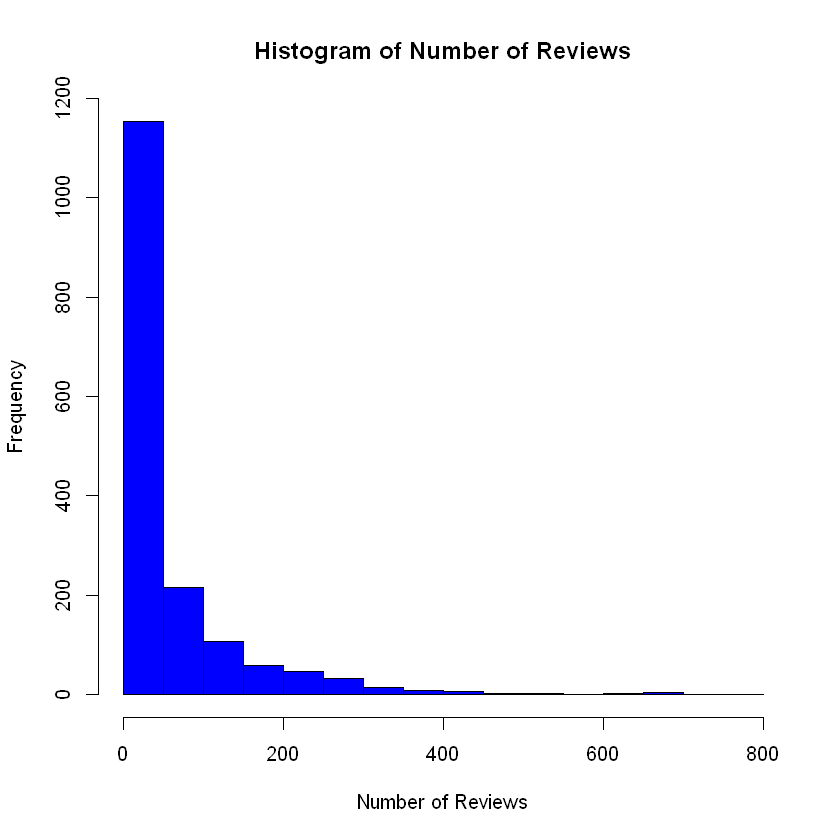

In [14]:
hist(df$number_of_reviews,
     main="Histogram of Number of Reviews",
     xlab="Number of Reviews",
     col="blue")

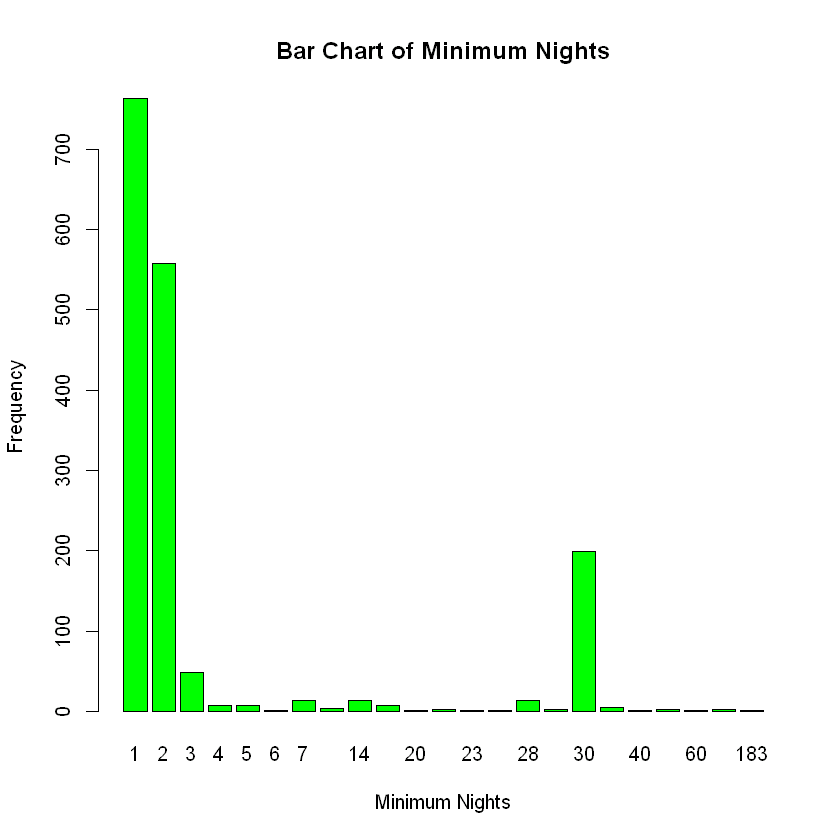

In [15]:
barplot(table(df$minimum_nights),
        main="Bar Chart of Minimum Nights",
        xlab="Minimum Nights",
        ylab="Frequency",
        col="green")

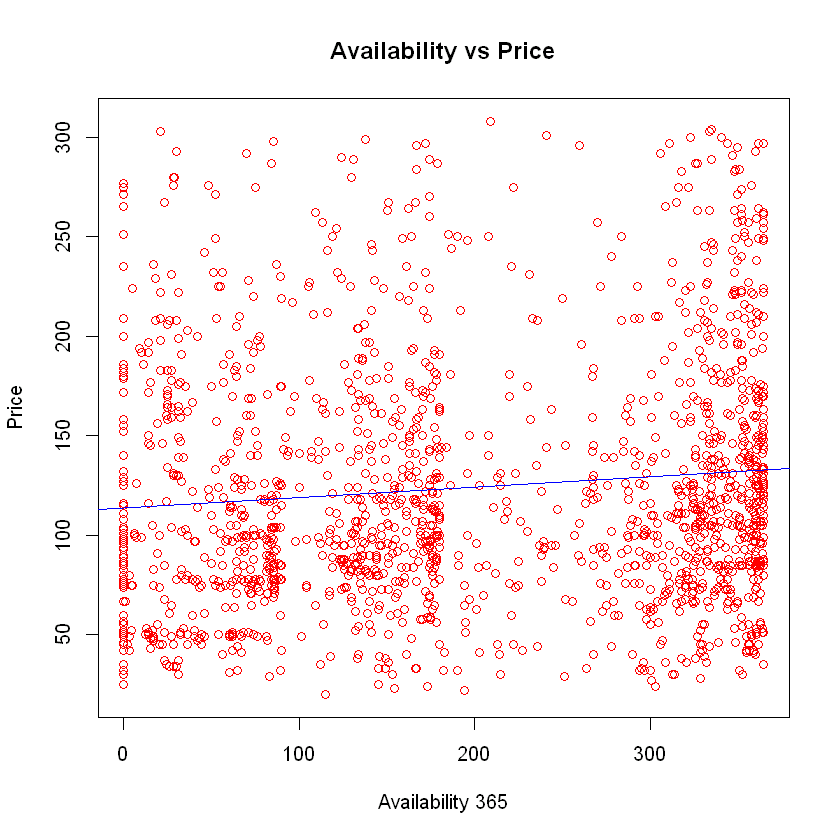

In [16]:
plot(df$availability_365, df$price,
     main="Availability vs Price",
     xlab="Availability 365",
     ylab="Price",
     col="red")

abline(lm(df$price ~ df$availability_365), col="blue")

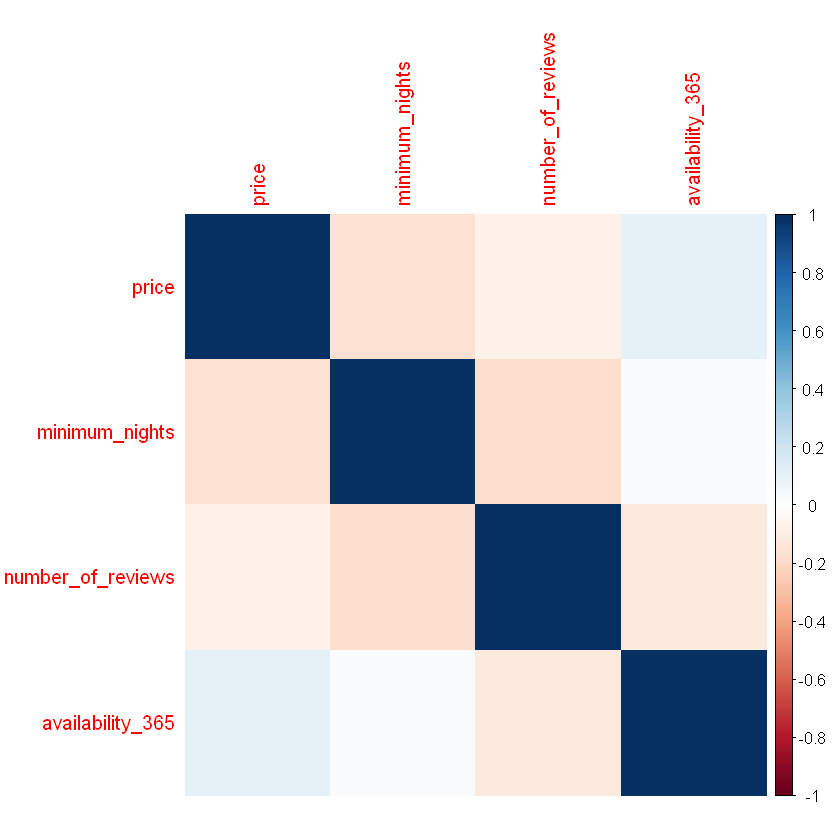

In [18]:
corr_matrix <- cor(df[, c("price", "minimum_nights", "number_of_reviews", "availability_365")])
corrplot(corr_matrix, method="color")